In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
%matplotlib inline

Load & Clean Spam dataset  
Tasks 1, 2, 3, 4

In [ ]:
# Load spam (standard format)
df_spam_raw = pd.read_csv('Datasets/spam.csv', encoding='latin-1')

# Clean: drop irrelevant columns
df_spam = df_spam_raw.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], errors='ignore')

# Rename meaningfully
df_spam = df_spam.rename(columns={'v1': 'label_raw', 'v2': 'message'})

# Convert labels to numeric
df_spam['is_spam'] = df_spam['label_raw'].map({'ham': 0, 'spam': 1})
df_spam = df_spam.drop(columns=['label_raw'])

# Remove duplicates
df_spam = df_spam.drop_duplicates(subset='message')

print("Spam cleaned shape:", df_spam.shape)
print("Class distribution:\n", df_spam['is_spam'].value_counts(normalize=True).round(4))

Spam cleaned shape: (5169, 2)
Class distribution:
 is_spam
0    0.8737
1    0.1263
Name: proportion, dtype: float64


# Cell 4 – Spam with CountVectorizer  
**Task 1: map text features using Logistic Regression and compute accuracy**  
**Task 2: precision, recall, F1 score**  
**Task 3: confusion matrix**

=== Task 1,2,3 - CountVectorizer ===
Accuracy:   0.9787
Precision:  0.9504
Recall:     0.8779
F1-score:   0.9127


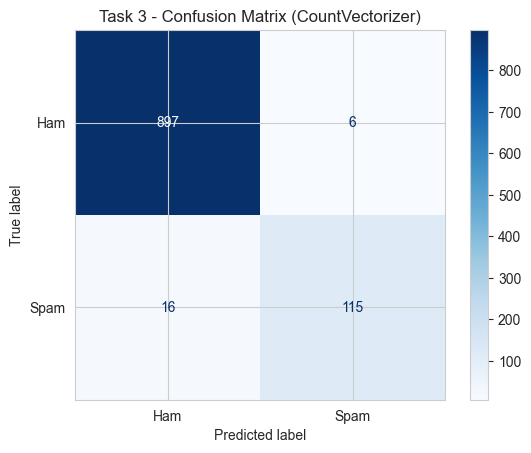

In [3]:
X_text = df_spam['message']
y_spam = df_spam['is_spam']

vec_count = CountVectorizer(stop_words='english', min_df=5)
X_count = vec_count.fit_transform(X_text)

X_tr, X_te, y_tr, y_te = train_test_split(X_count, y_spam, test_size=0.2, random_state=42, stratify=y_spam)

model_count = LogisticRegression(max_iter=1000, class_weight='balanced')
model_count.fit(X_tr, y_tr)
y_pred_count = model_count.predict(X_te)

print("=== Task 1,2,3 - CountVectorizer ===")
print(f"Accuracy:   {accuracy_score(y_te, y_pred_count):.4f}")
print(f"Precision:  {precision_score(y_te, y_pred_count):.4f}")
print(f"Recall:     {recall_score(y_te, y_pred_count):.4f}")
print(f"F1-score:   {f1_score(y_te, y_pred_count):.4f}")

cm = confusion_matrix(y_te, y_pred_count)
disp = ConfusionMatrixDisplay(cm, display_labels=['Ham','Spam'])
disp.plot(cmap='Blues')
plt.title("Task 3 - Confusion Matrix (CountVectorizer)")
plt.show()

# Cell 5 – Spam with TF-IDF  
**Task 4: compare performance with different feature extraction methods (CountVectorizer vs TF-IDF)**


In [4]:
vec_tfidf = TfidfVectorizer(stop_words='english', min_df=5, ngram_range=(1,2))
X_tfidf = vec_tfidf.fit_transform(X_text)

X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(X_tfidf, y_spam, test_size=0.2, random_state=42, stratify=y_spam)

model_tfidf = LogisticRegression(max_iter=1000, class_weight='balanced')
model_tfidf.fit(X_tr_t, y_tr_t)
y_pred_tfidf = model_tfidf.predict(X_te_t)

print("=== Task 4 - TF-IDF ===")
print(f"Accuracy:   {accuracy_score(y_te_t, y_pred_tfidf):.4f}")
print(f"Precision:  {precision_score(y_te_t, y_pred_tfidf):.4f}")
print(f"Recall:     {recall_score(y_te_t, y_pred_tfidf):.4f}")
print(f"F1-score:   {f1_score(y_te_t, y_pred_tfidf):.4f}")

=== Task 4 - TF-IDF ===
Accuracy:   0.9787
Precision:  0.9360
Recall:     0.8931
F1-score:   0.9141


# Cell 6 – Load & Clean Titanic  
**Tasks 5,6,7,8**

In [ ]:
df_tit_raw = pd.read_csv('Datasets/Titanic-Dataset.csv')

# Drop irrelevant columns
df_tit = df_tit_raw.drop(columns=['PassengerId','Name','Ticket','Cabin'], errors='ignore')

# Handle missing values
df_tit['Age'] = df_tit['Age'].fillna(df_tit['Age'].median())
df_tit['Embarked'] = df_tit['Embarked'].fillna(df_tit['Embarked'].mode()[0])
df_tit['Fare'] = df_tit['Fare'].fillna(df_tit['Fare'].median())

# Encode categoricals
df_tit = pd.get_dummies(df_tit, columns=['Sex','Embarked'], drop_first=True)

print("Titanic cleaned shape:", df_tit.shape)

Titanic cleaned shape: (891, 9)


# Cell 7 – Titanic basic model  
**Task 5: predict outcomes and compute accuracy**  
**Task 6: precision and recall**  
**Task 7: F1 score**

In [14]:
X_tit = df_tit.drop('Survived', axis=1)
y_tit = df_tit['Survived']

X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(X_tit, y_tit, test_size=0.2, random_state=42, stratify=y_tit)

model_tit = LogisticRegression(max_iter=1000)
model_tit.fit(X_tr_t, y_tr_t)
y_pred_tit = model_tit.predict(X_te_t)

print("=== Tasks 5,6,7 - Titanic ===")
print(f"Accuracy:   {accuracy_score(y_te_t, y_pred_tit):.4f}")
print(f"Precision:  {precision_score(y_te_t, y_pred_tit):.4f}")
print(f"Recall:     {recall_score(y_te_t, y_pred_tit):.4f}")
print(f"F1-score:   {f1_score(y_te_t, y_pred_tit):.4f}")

=== Tasks 5,6,7 - Titanic ===
Accuracy:   0.8045
Precision:  0.7931
Recall:     0.6667
F1-score:   0.7244


# Cell 8 – Titanic missing values comparison  
**Task 8: compare accuracy before and after handling missing values**

In [15]:
# Before - drop rows with missing Age/Embarked
df_before = df_tit_raw.dropna(subset=['Age','Embarked'])
df_before = pd.get_dummies(df_before, columns=['Sex','Embarked'], drop_first=True)
X_b = df_before.drop(['Survived','PassengerId','Name','Ticket','Cabin'], axis=1, errors='ignore')
y_b = df_before['Survived']

acc_before = cross_val_score(LogisticRegression(max_iter=1000), X_b, y_b, cv=5).mean()

# After - our cleaned version
acc_after = cross_val_score(LogisticRegression(max_iter=1000), X_tit, y_tit, cv=5).mean()

print("=== Task 8 ===")
print(f"Accuracy BEFORE handling missing values (CV5): {acc_before:.4f}")
print(f"Accuracy AFTER handling missing values (CV5):  {acc_after:.4f}")

=== Task 8 ===
Accuracy BEFORE handling missing values (CV5): 0.7879
Accuracy AFTER handling missing values (CV5):  0.7912


# Cell 9 – Load & Clean Iris  
**Tasks 9,10,11,12**

In [ ]:
df_iris = pd.read_csv('Datasets/Iris.csv')
df_iris = df_iris.drop(columns=['Id'], errors='ignore')

le = LabelEncoder()
df_iris['species_code'] = le.fit_transform(df_iris['Species'])

print("Iris cleaned shape:", df_iris.shape)
print(df_iris['Species'].value_counts())

Iris cleaned shape: (150, 6)
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


# Cell 10 – Iris full features  
**Task 9: map features to targets and compute accuracy**  
**Task 10: precision, recall, F1 score**

In [9]:
X_iris_full = df_iris.drop(['Species','species_code'], axis=1)
y_iris = df_iris['species_code']

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(X_iris_full, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

model_iris = LogisticRegression(max_iter=1000)
model_iris.fit(X_tr_i, y_tr_i)
y_pred_iris = model_iris.predict(X_te_i)

print("=== Tasks 9,10 - Iris full features ===")
print(f"Accuracy:          {accuracy_score(y_te_i, y_pred_iris):.4f}")
print(f"Precision (macro): {precision_score(y_te_i, y_pred_iris, average='macro'):.4f}")
print(f"Recall (macro):    {recall_score(y_te_i, y_pred_iris, average='macro'):.4f}")
print(f"F1-score (macro):  {f1_score(y_te_i, y_pred_iris, average='macro'):.4f}")

=== Tasks 9,10 - Iris full features ===
Accuracy:          0.9667
Precision (macro): 0.9697
Recall (macro):    0.9667
F1-score (macro):  0.9666


# Cell 11 – Iris two features  
**Task 11: train with only two feature columns and report accuracy**

In [12]:
X_two = df_iris[['PetalLengthCm', 'PetalWidthCm']]

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_two, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

model_two = LogisticRegression(max_iter=1000)
model_two.fit(X_tr2, y_tr2)

acc_two = accuracy_score(y_te2, model_two.predict(X_te2))
print("=== Task 11 ===")
print(f"Accuracy with only Petal Length & Petal Width: {acc_two:.4f}")

=== Task 11 ===
Accuracy with only Petal Length & Petal Width: 0.9667


# Cell 12 – Iris decision boundary  
**Task 12: visualize decision boundaries for two classes + accuracy**

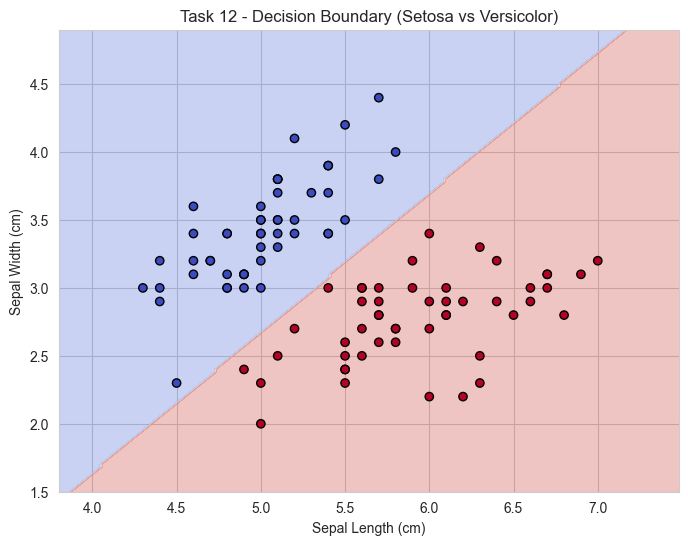

Task 12 - Training set accuracy (2 classes): 1.0


In [11]:
# Setosa (0) vs Versicolor (1) using first two features
mask = y_iris < 2
X_bound = df_iris.loc[mask, ['SepalLengthCm','SepalWidthCm']].values
y_bound = y_iris[mask]

model_bound = LogisticRegression().fit(X_bound, y_bound)

x_min, x_max = X_bound[:,0].min()-0.5, X_bound[:,0].max()+0.5
y_min, y_max = X_bound[:,1].min()-0.5, X_bound[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = model_bound.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_bound[:,0], X_bound[:,1], c=y_bound, cmap='coolwarm', edgecolor='k')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Task 12 - Decision Boundary (Setosa vs Versicolor)')
plt.show()

print("Task 12 - Training set accuracy (2 classes):", accuracy_score(y_bound, model_bound.predict(X_bound)))

# Cell 13 – Load & Clean Heart  
**Tasks 13,14,15,16**

In [ ]:
df_heart = pd.read_csv('Datasets/heart.csv')

# Minor renaming for clarity
df_heart = df_heart.rename(columns={
    'cp': 'chest_pain_type',
    'trestbps': 'resting_bp',
    'thalach': 'max_hr'
})

print("Heart cleaned shape:", df_heart.shape)

Heart cleaned shape: (1025, 14)


# Cell 14 – Heart basic model + metrics + confusion matrix  
**Task 13: train Logistic Regression and compute accuracy**  
**Task 14: precision, recall, F1 score**  
**Task 16: plot confusion matrix**

=== Tasks 13,14 - Heart Disease ===
Accuracy:  0.8146
Precision: 0.7638
Recall:    0.9238
F1-score:  0.8362


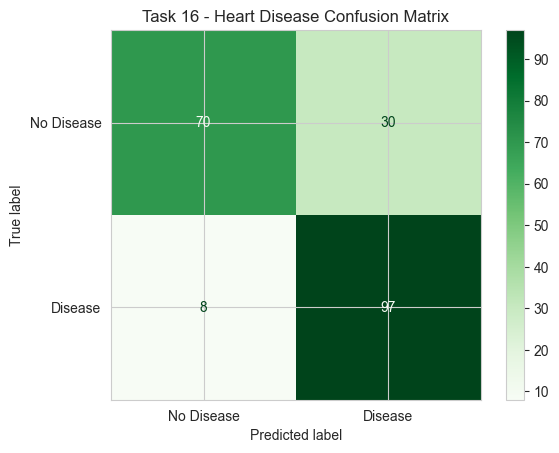

In [7]:
X_heart = df_heart.drop('target', axis=1)
y_heart = df_heart['target']

X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart)

model_heart = LogisticRegression(max_iter=2000)
model_heart.fit(X_tr_h, y_tr_h)
y_pred_h = model_heart.predict(X_te_h)

print("=== Tasks 13,14 - Heart Disease ===")
print(f"Accuracy:  {accuracy_score(y_te_h, y_pred_h):.4f}")
print(f"Precision: {precision_score(y_te_h, y_pred_h):.4f}")
print(f"Recall:    {recall_score(y_te_h, y_pred_h):.4f}")
print(f"F1-score:  {f1_score(y_te_h, y_pred_h):.4f}")

# Task 16
cm_h = confusion_matrix(y_te_h, y_pred_h)
disp_h = ConfusionMatrixDisplay(cm_h, display_labels=['No Disease','Disease'])
disp_h.plot(cmap='Greens')
plt.title("Task 16 - Heart Disease Confusion Matrix")
plt.show()

# Cell 15 – Heart different split ratios  
**Task 15: compare results using different train-test split ratios**

In [ ]:
print("=== Task 15 - Different split ratios ===")
for test_size in [0.15, 0.20, 0.30, 0.40]:
    X_tr, X_te, y_tr, y_te = train_test_split(X_heart, y_heart, test_size=test_size, random_state=42, stratify=y_heart)
    m = LogisticRegression(max_iter=2000)
    m.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, m.predict(X_te))
    print(f"Test size {test_size:.2f} → Accuracy: {acc:.4f}")


=== Task 15 - Different split ratios ===
Test size 0.15 → Accuracy: 0.8442
Test size 0.20 → Accuracy: 0.8146
Test size 0.30 → Accuracy: 0.8247
Test size 0.40 → Accuracy: 0.8293


# Cell 16 – Final comparison tasks  
**Task 17: Titanic vs Heart accuracy**  
**Task 18: Iris vs Titanic precision/recall**  
**Task 19: Spam vs Heart F1**  
**Task 20: cross-validation on Iris and Titanic**

In [22]:
print("=== Tasks 17–20 ===")

# Task 17
print(f"Task 17 - Titanic Accuracy: {accuracy_score(y_te_t, y_pred_tit):.4f}")
print(f"           Heart Accuracy:   {accuracy_score(y_te_h, y_pred_h):.4f}")

# Task 18
print(f"Task 18 - Iris Precision/Recall (macro): "
      f"{precision_score(y_te_i, y_pred_iris, average='macro'):.4f} / "
      f"{recall_score(y_te_i, y_pred_iris, average='macro'):.4f}")
print(f"           Titanic Precision/Recall: "
      f"{precision_score(y_te_t, y_pred_tit):.4f} / "
      f"{recall_score(y_te_t, y_pred_tit):.4f}")

# Task 19
print(f"Task 19 - Spam F1 (TF-IDF):   {f1_score(y_te_t, y_pred_tfidf):.4f}")
print(f"           Heart F1:           {f1_score(y_te_h, y_pred_h):.4f}")

# Task 20
cv_iris   = cross_val_score(LogisticRegression(max_iter=1000), X_iris_full, y_iris, cv=5).mean()
cv_titanic = cross_val_score(LogisticRegression(max_iter=1000), X_tit, y_tit, cv=5).mean()
print(f"Task 20 - Iris CV5 avg accuracy:   {cv_iris:.4f}")
print(f"           Titanic CV5 avg accuracy: {cv_titanic:.4f}")

=== Tasks 17–20 ===
Task 17 - Titanic Accuracy: 0.8045
           Heart Accuracy:   0.8146
Task 18 - Iris Precision/Recall (macro): 0.9697 / 0.9667
           Titanic Precision/Recall: 0.7931 / 0.6667


ValueError: Found input variables with inconsistent numbers of samples: [179, 1034]